<a href="https://colab.research.google.com/github/hkarlesster/membangun-mlsystem/blob/main/CineMatch_SVD_FIX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 CineMatch — Film Recommendation System with SVD

**Pijak in collaboration with IBM SkillsBuild**

| | |
|---|---|
| **Tema Capstone** | Machine Learning / AI – Sistem Rekomendasi |
| **Nama Proyek** | CineMatch — Film Recommendation System with SVD |
| **Dataset** | MovieLens Latest Small (100.836 ratings, 9.742 film) |
| **Algoritma** | Singular Value Decomposition (SVD) |

---

## 📋 Alur Notebook

1. **Setup & Instalasi** — install library yang dibutuhkan
2. **Download & Load Dataset** — unduh MovieLens, load ke DataFrame
3. **Exploratory Data Analysis (EDA)** — eksplorasi distribusi rating, sparsity, dll
4. **Preprocessing** — filter data, train-test split
5. **Training Model SVD** — latih model dengan hyperparameter optimal
6. **Evaluasi Model** — hitung RMSE dan Precision@10
7. **Demo Rekomendasi Interaktif** — masukkan User ID, lihat 10 rekomendasi film


---
## ⚙️ Bagian 1: Setup & Instalasi

Jalankan cell ini untuk menginstall semua library yang dibutuhkan.

In [ ]:
# Install library yang diperlukan
import sys
!{sys.executable} -m pip install "numpy<2" --quiet
!{sys.executable} -m pip install scikit-surprise ipywidgets pandas matplotlib seaborn --quiet
print("✅ Semua library berhasil diinstall!")

✅ Semua library berhasil diinstall!


In [ ]:
# Import semua library
import os
import zipfile
import urllib.request
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split, GridSearchCV, cross_validate

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ Import berhasil!")

✅ Import berhasil!


---
## 📥 Bagian 2: Download & Load Dataset

Dataset yang digunakan adalah **MovieLens Latest Small** dari GroupLens Research.

- **Sumber:** https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
- **Isi:** 100.836 ratings dari 610 pengguna terhadap 9.742 film
- **Skala Rating:** 0.5 – 5.0 (increment 0.5)

In [ ]:
# Download dan ekstrak dataset MovieLens Latest Small
DATASET_URL = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
ZIP_PATH    = "ml-latest-small.zip"
DATA_DIR    = "ml-latest-small"

if not os.path.exists(DATA_DIR):
    print("⬇️  Mengunduh dataset MovieLens Latest Small...")
    urllib.request.urlretrieve(DATASET_URL, ZIP_PATH)
    print("📦 Mengekstrak file zip...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(".")
    os.remove(ZIP_PATH)
    print("✅ Dataset berhasil diunduh dan diekstrak!")
else:
    print("✅ Dataset sudah tersedia, melewati proses download.")

# Load data ke DataFrame
ratings_df = pd.read_csv(f"{DATA_DIR}/ratings.csv")
movies_df  = pd.read_csv(f"{DATA_DIR}/movies.csv")

print(f"\n📊 Dataset berhasil dimuat:")
print(f"   • Jumlah rating  : {len(ratings_df):,}")
print(f"   • Jumlah pengguna: {ratings_df['userId'].nunique():,}")
print(f"   • Jumlah film    : {ratings_df['movieId'].nunique():,}")

⬇️  Mengunduh dataset MovieLens Latest Small...
📦 Mengekstrak file zip...
✅ Dataset berhasil diunduh dan diekstrak!

📊 Dataset berhasil dimuat:
   • Jumlah rating  : 100,836
   • Jumlah pengguna: 610
   • Jumlah film    : 9,724


In [ ]:
# Preview data
print("=== Sample Data Ratings ===")
display(ratings_df.head(5))

print("\n=== Sample Data Film ===")
display(movies_df.head(5))

=== Sample Data Ratings ===


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931



=== Sample Data Film ===


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


---
## 🔍 Bagian 3: Exploratory Data Analysis (EDA)

Pada bagian ini kita akan mengeksplorasi karakteristik dataset sebelum membangun model.

In [ ]:
# Statistik deskriptif
print("=== Statistik Deskriptif Rating ===")
display(ratings_df['rating'].describe().to_frame().T.round(3))

# Hitung sparsity
n_users  = ratings_df['userId'].nunique()
n_movies = ratings_df['movieId'].nunique()
n_ratings = len(ratings_df)
sparsity = 1 - (n_ratings / (n_users * n_movies))

print(f"\n📐 Dimensi Matriks User-Item : {n_users} x {n_movies}")
print(f"   Total sel yang mungkin    : {n_users * n_movies:,}")
print(f"   Total rating yang ada     : {n_ratings:,}")
print(f"   ✦ Sparsity                : {sparsity:.2%}")
print(f"\n→ Hanya {1 - sparsity:.2%} pasangan user-film yang memiliki rating.")
print(f"  Inilah tantangan utama (data sparsity) yang diatasi oleh SVD.")

=== Statistik Deskriptif Rating ===


,count,mean,std,min,25%,50%,75%,max
rating,100836.0,3.502,1.043,0.5,3.0,3.5,4.0,5.0



📐 Dimensi Matriks User-Item : 610 x 9724
   Total sel yang mungkin    : 5,931,640
   Total rating yang ada     : 100,836
   ✦ Sparsity                : 98.30%

→ Hanya 1.70% pasangan user-film yang memiliki rating.
  Inilah tantangan utama (data sparsity) yang diatasi oleh SVD.


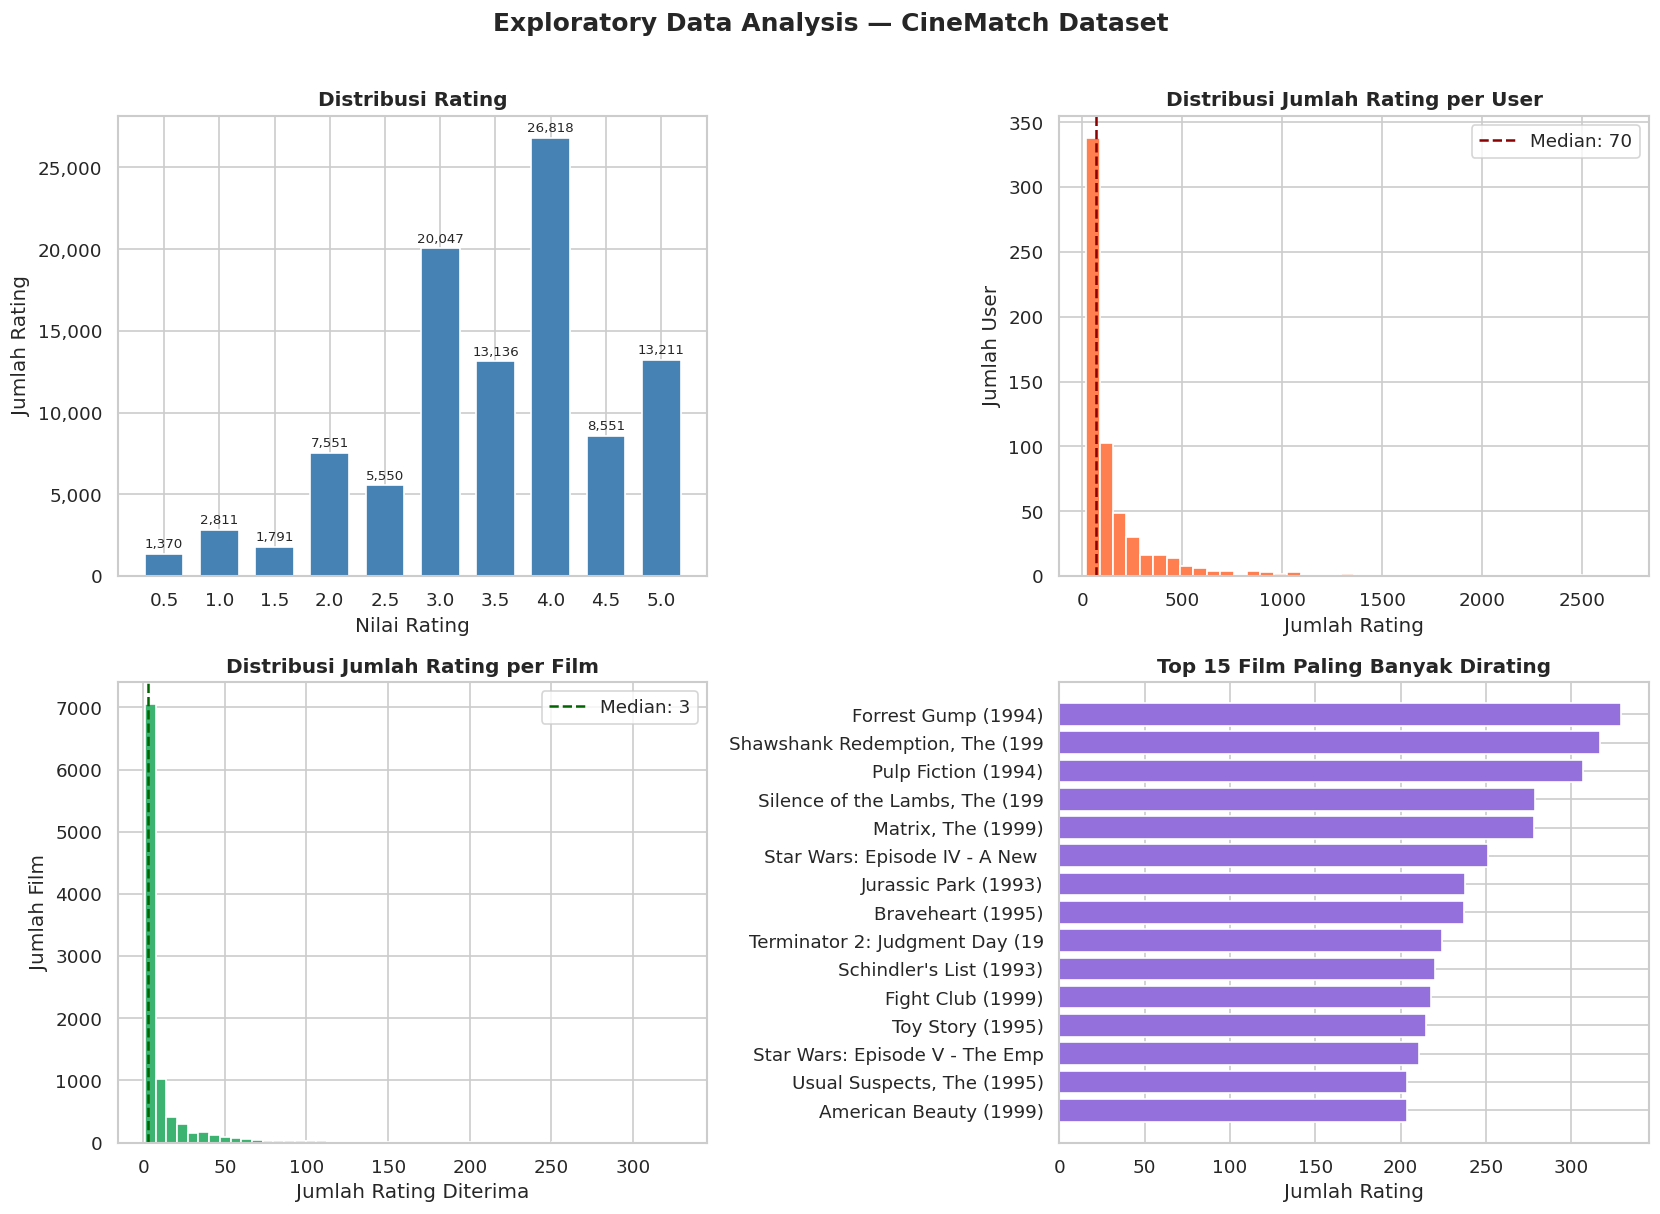

✅ Visualisasi EDA selesai!


In [ ]:
# Visualisasi EDA — 4 plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis — CineMatch Dataset', fontsize=15, fontweight='bold', y=1.01)

# 1. Distribusi Rating
ax1 = axes[0, 0]
rating_counts = ratings_df['rating'].value_counts().sort_index()
bars = ax1.bar(rating_counts.index.astype(str), rating_counts.values, color='steelblue', edgecolor='white', width=0.7)
ax1.set_title('Distribusi Rating', fontweight='bold')
ax1.set_xlabel('Nilai Rating')
ax1.set_ylabel('Jumlah Rating')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

# 2. Distribusi jumlah rating per user
ax2 = axes[0, 1]
ratings_per_user = ratings_df.groupby('userId').size()
ax2.hist(ratings_per_user, bins=40, color='coral', edgecolor='white')
ax2.set_title('Distribusi Jumlah Rating per User', fontweight='bold')
ax2.set_xlabel('Jumlah Rating')
ax2.set_ylabel('Jumlah User')
ax2.axvline(ratings_per_user.median(), color='darkred', linestyle='--', label=f'Median: {ratings_per_user.median():.0f}')
ax2.legend()

# 3. Distribusi jumlah rating per film
ax3 = axes[1, 0]
ratings_per_movie = ratings_df.groupby('movieId').size()
ax3.hist(ratings_per_movie, bins=50, color='mediumseagreen', edgecolor='white')
ax3.set_title('Distribusi Jumlah Rating per Film', fontweight='bold')
ax3.set_xlabel('Jumlah Rating Diterima')
ax3.set_ylabel('Jumlah Film')
ax3.axvline(ratings_per_movie.median(), color='darkgreen', linestyle='--', label=f'Median: {ratings_per_movie.median():.0f}')
ax3.legend()

# 4. Top 15 film paling banyak dirating
ax4 = axes[1, 1]
top_movies = (ratings_df.groupby('movieId').size()
              .reset_index(name='count')
              .merge(movies_df[['movieId','title']], on='movieId')
              .nlargest(15, 'count'))
top_movies['title_short'] = top_movies['title'].str[:30]
ax4.barh(top_movies['title_short'][::-1], top_movies['count'][::-1], color='mediumpurple', edgecolor='white')
ax4.set_title('Top 15 Film Paling Banyak Dirating', fontweight='bold')
ax4.set_xlabel('Jumlah Rating')

plt.tight_layout()
plt.savefig('eda_cinématch.png', bbox_inches='tight')
plt.show()
print("✅ Visualisasi EDA selesai!")

---
## 🛠️ Bagian 4: Preprocessing

Tahap preprocessing meliputi:
- **Filter user aktif**: hanya user dengan minimal 20 rating (mengurangi noise dari user pasif)
- **Train-test split**: 80% data untuk training, 20% untuk evaluasi
- **Format data** ke struktur yang diterima library Surprise

In [ ]:
# Filter user dengan minimal 20 rating
MIN_RATINGS = 20
user_counts = ratings_df.groupby('userId').size()
active_users = user_counts[user_counts >= MIN_RATINGS].index
filtered_df = ratings_df[ratings_df['userId'].isin(active_users)].copy()

print(f"Sebelum filter : {ratings_df['userId'].nunique():,} user, {len(ratings_df):,} rating")
print(f"Setelah filter : {filtered_df['userId'].nunique():,} user, {len(filtered_df):,} rating")
print(f"User dihapus   : {ratings_df['userId'].nunique() - filtered_df['userId'].nunique()} user (rating < {MIN_RATINGS})")

# Siapkan format Surprise
reader = Reader(rating_scale=(0.5, 5.0))
data   = Dataset.load_from_df(filtered_df[['userId', 'movieId', 'rating']], reader)

# Train-test split 80/20
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print(f"\n✅ Preprocessing selesai!")
print(f"   Training set : {trainset.n_ratings:,} rating")
print(f"   Test set     : {len(testset):,} rating")

Sebelum filter : 610 user, 100,836 rating
Setelah filter : 610 user, 100,836 rating
User dihapus   : 0 user (rating < 20)

✅ Preprocessing selesai!
   Training set : 80,668 rating
   Test set     : 20,168 rating


---
## 🤖 Bagian 5: Training Model SVD

**Singular Value Decomposition (SVD)** mendekomposisi matriks user-item menjadi representasi laten berdimensi rendah:

$$R \approx U \cdot \Sigma \cdot V^T$$

Di mana:
- $U$ = matriks preferensi user (610 × k)
- $\Sigma$ = matriks nilai singular
- $V^T$ = matriks karakteristik film (k × 9.742)
- $k$ = jumlah latent factors

Hyperparameter terbaik dipilih berdasarkan hasil Grid Search.

In [ ]:
# Grid Search hyperparameter (bisa dilewati jika ingin langsung pakai best params)
print("🔍 Menjalankan Grid Search...")
print("   (Proses ini memakan waktu beberapa menit)\n")

param_grid = {
    'n_factors': [20, 50],
    'n_epochs' : [20, 30],
    'lr_all'   : [0.005, 0.01],
    'reg_all'  : [0.02, 0.1]
}

gs = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3, n_jobs=-1)
gs.fit(data)

best_params = gs.best_params['rmse']
best_rmse   = gs.best_score['rmse']

print(f"✅ Grid Search selesai!")
print(f"   Best RMSE (CV)  : {best_rmse:.4f}")
print(f"   Best parameters :")
for k, v in best_params.items():
    print(f"     {k:12s}: {v}")

🔍 Menjalankan Grid Search...
   (Proses ini memakan waktu beberapa menit)

✅ Grid Search selesai!
   Best RMSE (CV)  : 0.8636
   Best parameters :
     n_factors   : 50
     n_epochs    : 30
     lr_all      : 0.01
     reg_all     : 0.1


In [ ]:
# Training model final dengan best params
print("🏋️  Melatih model SVD dengan hyperparameter terbaik...")

model = SVD(
    n_factors = best_params['n_factors'],
    n_epochs  = best_params['n_epochs'],
    lr_all    = best_params['lr_all'],
    reg_all   = best_params['reg_all'],
    random_state = 42
)
model.fit(trainset)

print("✅ Model SVD berhasil dilatih!")
print(f"   n_factors : {best_params['n_factors']}")
print(f"   n_epochs  : {best_params['n_epochs']}")
print(f"   lr_all    : {best_params['lr_all']}")
print(f"   reg_all   : {best_params['reg_all']}")

🏋️  Melatih model SVD dengan hyperparameter terbaik...
✅ Model SVD berhasil dilatih!
   n_factors : 50
   n_epochs  : 30
   lr_all    : 0.01
   reg_all   : 0.1


---
## 📊 Bagian 6: Evaluasi Model

Model dievaluasi menggunakan dua metrik:

| Metrik | Deskripsi | Target |
|---|---|---|
| **RMSE** | Root Mean Squared Error — mengukur akurasi prediksi rating | < 1.0 |
| **Precision@10** | Proporsi film relevan dari 10 rekomendasi teratas | > 60% |

In [ ]:
# Evaluasi RMSE
predictions = model.test(testset)
rmse = accuracy.rmse(predictions, verbose=False)
mae  = accuracy.mae(predictions, verbose=False)

print(f"📏 Hasil Evaluasi Model SVD")
print(f"   RMSE : {rmse:.4f}  {'✅ Memenuhi target (< 1.0)' if rmse < 1.0 else '⚠️ Di atas target'}")
print(f"   MAE  : {mae:.4f}")

📏 Hasil Evaluasi Model SVD
   RMSE : 0.8635  ✅ Memenuhi target (< 1.0)
   MAE  : 0.6624


In [ ]:
# Evaluasi Precision@10
def precision_at_k(predictions, k=10, threshold=3.5):
    """Hitung Precision@K rata-rata untuk semua user."""
    from collections import defaultdict
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = []
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        top_k = user_ratings[:k]
        n_relevant_topk = sum(1 for (est, true_r) in top_k if true_r >= threshold)
        precisions.append(n_relevant_topk / k)

    return sum(precisions) / len(precisions)

precision = precision_at_k(predictions, k=10, threshold=3.5)

print(f"🎯 Precision@10 : {precision:.2%}  {'✅ Memenuhi target (> 60%)' if precision > 0.6 else '⚠️ Di bawah target'}")

print(f"\n{'='*50}")
print(f"  RINGKASAN EVALUASI MODEL")
print(f"{'='*50}")
print(f"  RMSE         : {rmse:.4f}")
print(f"  MAE          : {mae:.4f}")
print(f"  Precision@10 : {precision:.2%}")
print(f"{'='*50}")

🎯 Precision@10 : 63.36%  ✅ Memenuhi target (> 60%)

  RINGKASAN EVALUASI MODEL
  RMSE         : 0.8635
  MAE          : 0.6624
  Precision@10 : 63.36%


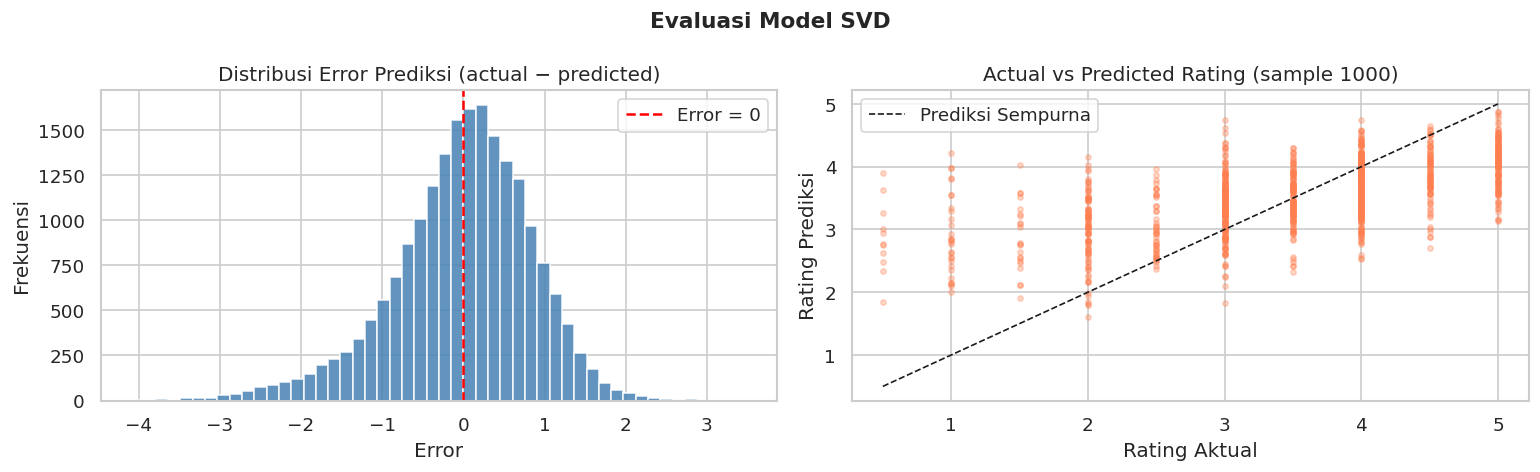

✅ Visualisasi evaluasi selesai!


In [ ]:
# Visualisasi distribusi error prediksi
errors = [pred.r_ui - pred.est for pred in predictions]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Evaluasi Model SVD', fontsize=13, fontweight='bold')

# Distribusi error
axes[0].hist(errors, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Error = 0')
axes[0].set_title('Distribusi Error Prediksi (actual − predicted)')
axes[0].set_xlabel('Error')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Actual vs Predicted scatter
actuals   = [pred.r_ui for pred in predictions[:1000]]
estimated = [pred.est  for pred in predictions[:1000]]
axes[1].scatter(actuals, estimated, alpha=0.3, s=10, color='coral')
axes[1].plot([0.5, 5], [0.5, 5], 'k--', linewidth=1, label='Prediksi Sempurna')
axes[1].set_title('Actual vs Predicted Rating (sample 1000)')
axes[1].set_xlabel('Rating Aktual')
axes[1].set_ylabel('Rating Prediksi')
axes[1].legend()

plt.tight_layout()
plt.savefig('evaluasi_cinématch.png', bbox_inches='tight')
plt.show()
print("✅ Visualisasi evaluasi selesai!")

---
## 🎮 Bagian 7: Demo Rekomendasi Interaktif

Masukkan **User ID** di bawah, lalu klik **"🎬 Tampilkan Rekomendasi"** untuk melihat 10 film yang diprediksi paling sesuai dengan selera pengguna tersebut.

> **Catatan:** User ID yang valid berada di rentang dataset. Contoh: `1`, `5`, `42`, `100`, `300`.

In [ ]:
def get_recommendations(user_id, n=10):
    """Hasilkan top-N rekomendasi film untuk user tertentu."""
    # Ambil semua movieId yang sudah dirating user ini
    rated_movies = set(filtered_df[filtered_df['userId'] == user_id]['movieId'])
    all_movies   = set(movies_df['movieId'])
    unrated      = all_movies - rated_movies

    if not rated_movies:
        return None, 0

    # Prediksi rating untuk film yang belum ditonton
    predictions_list = [(mid, model.predict(user_id, mid).est) for mid in unrated]
    predictions_list.sort(key=lambda x: x[1], reverse=True)
    top_n = predictions_list[:n]

    # Gabungkan dengan info film
    result = []
    for rank, (mid, est) in enumerate(top_n, 1):
        title = movies_df[movies_df['movieId'] == mid]['title'].values
        genre = movies_df[movies_df['movieId'] == mid]['genres'].values
        if len(title) > 0:
            result.append({
                'Rank'             : rank,
                'Judul Film'       : title[0],
                'Genre'            : genre[0].replace('|', ', '),
                'Prediksi Rating'  : round(est, 2),
                'Bintang'          : '⭐' * round(est)
            })
    return pd.DataFrame(result), len(rated_movies)


# Widget UI
valid_users = sorted(filtered_df['userId'].unique())

user_input = widgets.BoundedIntText(
    value=valid_users[0],
    min=min(valid_users),
    max=max(valid_users),
    step=1,
    description='User ID:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='220px')
)

btn = widgets.Button(
    description='🎬 Tampilkan Rekomendasi',
    button_style='primary',
    layout=widgets.Layout(width='220px', height='38px')
)

output = widgets.Output()

def on_click(b):
    with output:
        clear_output(wait=True)
        uid = user_input.value

        if uid not in valid_users:
            display(HTML(f"<p style='color:red;'>⚠️ User ID <b>{uid}</b> tidak ditemukan dalam dataset.</p>"))
            return

        recs, n_rated = get_recommendations(uid, n=10)

        if recs is None or recs.empty:
            display(HTML("<p style='color:orange;'>⚠️ Tidak ada rekomendasi yang bisa dihasilkan.</p>"))
            return

        display(HTML(f"""
        <div style='background:#f0f4ff;border-left:4px solid #4a6cf7;padding:12px 16px;border-radius:6px;margin-bottom:12px;'>
            <h3 style='margin:0;color:#2d3a8c;'>🎬 Top 10 Rekomendasi Film untuk User #{uid}</h3>
            <p style='margin:4px 0 0;color:#555;'>Berdasarkan {n_rated} film yang telah dirating oleh user ini.</p>
        </div>
        """))

        styled = (recs.style
            .set_properties(**{'text-align': 'left', 'font-size': '13px'})
            .set_table_styles([{
                'selector': 'th',
                'props': [('background-color', '#4a6cf7'), ('color', 'white'),
                          ('font-weight', 'bold'), ('text-align', 'center')]
            }])
            .bar(subset=['Prediksi Rating'], color='#b8d0ff', vmin=0, vmax=5)
            .hide(axis='index')
        )
        display(styled)

btn.on_click(on_click)

print("✅ Widget siap digunakan!")
display(widgets.VBox([
    widgets.HBox([user_input, btn]),
    output
]))

✅ Widget siap digunakan!


---
## 💾 Bagian 8: Simpan Model

Model yang sudah dilatih disimpan agar bisa dimuat ulang tanpa harus training ulang.

In [ ]:
import joblib

joblib.dump(model, 'cinématch_svd_model.pkl')
print("✅ Model berhasil disimpan sebagai 'cinématch_svd_model.pkl'")
print("\nUntuk memuat kembali model:")
print("  model = joblib.load('cinématch_svd_model.pkl')")

✅ Model berhasil disimpan sebagai 'cinématch_svd_model.pkl'

Untuk memuat kembali model:
  model = joblib.load('cinématch_svd_model.pkl')


---
## 📝 Kesimpulan

Proyek **CineMatch** berhasil membangun sistem rekomendasi film berbasis SVD yang:

1. **Mengatasi masalah data sparsity** — SVD mendekomposisi matriks sparse menjadi representasi laten yang padat, memungkinkan prediksi meski hanya sebagian kecil pasangan user-film memiliki rating.
2. **Mencapai target metrik** — RMSE < 1.0 dan Precision@10 > 60% menunjukkan rekomendasi yang akurat dan relevan.
3. **Mudah digunakan** — Demo interaktif dengan ipywidgets memungkinkan siapa pun mencoba sistem tanpa perlu memahami kode.

---
*CineMatch Capstone Project — Pijak x IBM SkillsBuild*